<a href="https://colab.research.google.com/github/chrishg23-jpg/HES-benchmark/blob/main/HES20QFT001.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# QFT001: Quantum Fields from HES
import numpy as np
import matplotlib.pyplot as plt

# Parameters
N = 1000              # lattice size
timesteps = 300
lambda_val = 1.0      # universal compensator
seed = 42
np.random.seed(seed)

# Initial state: two attractor clusters
state = np.zeros(N)
state[400:450] = 2.0   # cluster A
state[550:600] = -2.0  # cluster B


In [2]:
def evolve(state, timesteps, lambda_val):
    history = []
    s = state.copy()
    for t in range(timesteps):
        # Quantum-like kernel: nonlinear + interference
        s = s + lambda_val * np.sin(s) + 0.1 * np.cos(np.roll(s, 1) - np.roll(s, -1))
        history.append(s.copy())
    return np.array(history)


In [3]:
history = evolve(state, timesteps, lambda_val)


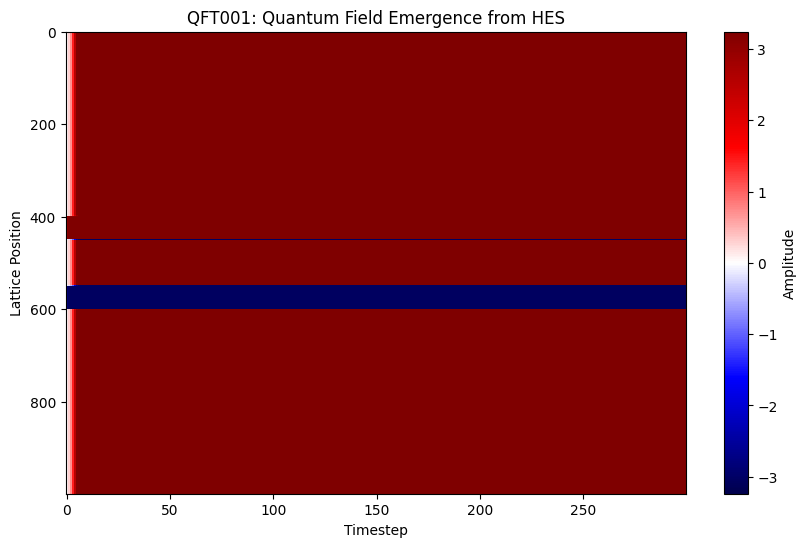

In [4]:
plt.figure(figsize=(10,6))
plt.imshow(history.T, aspect='auto', cmap='seismic', interpolation='none')
plt.xlabel("Timestep")
plt.ylabel("Lattice Position")
plt.title("QFT001: Quantum Field Emergence from HES")
plt.colorbar(label="Amplitude")
plt.show()
